<a href="https://colab.research.google.com/github/hellyaxs/MW-CL-pesquisa-tcc/blob/main/codigos/gerar_graficos_estatisticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gráficos Estatísticos — TCC

Gera:
- Mann–Whitney U (distribuição + estatística)
- Cliff's Delta (comparações par a par + escala)
- Perfil de uso de IA generativa (TCLE)

## 1. Montar o Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Caminhos

Edite as variáveis abaixo conforme seus diretórios no Drive.

In [ ]:
CAMINHO_ARQUIVO = "/content/drive/MyDrive/Colab Notebooks/codigo projeto tcc/Experimento - Elias.xlsx"
DIRETORIO_SAIDA = "/content/drive/MyDrive/Colab Notebooks/codigo projeto tcc/"  # onde os PNGs serão salvos

## 3. Instalar dependências

In [ ]:
!pip install -q openpyxl scipy numpy matplotlib

## 4. Código da análise (funções auxiliares)

In [ ]:
from pathlib import Path
from statistics import mean, median, stdev

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import FancyBboxPatch
from openpyxl import load_workbook
from scipy.stats import mannwhitneyu, shapiro

ALPHA = 0.05
ABA_COM_GPT = "Usou ChatGPT"
ABA_SEM_GPT = "Não Usou"

AZUL = "#001f4d"
OURO = "#c9a227"
TEXTO_SUAVE = "#5b6472"
BORDA = "#d7deed"
AZUL_CLARO = "#e8eef8"
FUNDO = "#f5f7fb"


def ler_pontuacoes(arquivo, aba):
    workbook = load_workbook(arquivo, data_only=True, read_only=True)
    if aba not in workbook.sheetnames:
        raise ValueError(
            f'A aba "{aba}" não foi encontrada. '
            f"Abas disponíveis: {', '.join(workbook.sheetnames)}"
        )
    pontuacoes = []
    worksheet = workbook[aba]
    for (valor,) in worksheet.iter_rows(
        min_row=2, min_col=2, max_col=2, values_only=True
    ):
        if valor is None:
            continue
        if isinstance(valor, str):
            valor = valor.split("/")[0].strip()
        try:
            pontuacoes.append(float(valor))
        except (TypeError, ValueError) as erro:
            raise ValueError(
                f'Pontuação inválida na aba "{aba}": {valor!r}'
            ) from erro
    if not pontuacoes:
        raise ValueError(f'Nenhuma pontuação foi encontrada na aba "{aba}".')
    return pontuacoes


def cliffs_delta(amostra_x, amostra_y):
    maiores = sum(x > y for x in amostra_x for y in amostra_y)
    menores = sum(x < y for x in amostra_x for y in amostra_y)
    return (maiores - menores) / (len(amostra_x) * len(amostra_y))


def formatar(numero, casas=3):
    return f"{numero:.{casas}f}".replace(".", ",")


def contar_pares(com_gpt, sem_gpt):
    maiores = sum(x > y for x in com_gpt for y in sem_gpt)
    menores = sum(x < y for x in com_gpt for y in sem_gpt)
    empates = sum(x == y for x in com_gpt for y in sem_gpt)
    return maiores, menores, empates


def estilizar_eixos(eixo):
    eixo.set_facecolor("#ffffff")
    eixo.spines["top"].set_visible(False)
    eixo.spines["right"].set_visible(False)
    eixo.spines["left"].set_color(BORDA)
    eixo.spines["bottom"].set_color(BORDA)
    eixo.tick_params(colors=AZUL)
    eixo.yaxis.grid(True, color=BORDA, linestyle="--", linewidth=0.7)
    eixo.set_axisbelow(True)

## 5. Carregar dados

In [ ]:
com_gpt = np.asarray(ler_pontuacoes(CAMINHO_ARQUIVO, ABA_COM_GPT), dtype=float)
sem_gpt = np.asarray(ler_pontuacoes(CAMINHO_ARQUIVO, ABA_SEM_GPT), dtype=float)

print(f"Com ChatGPT: {len(com_gpt)} amostras")
print(f"Sem ChatGPT: {len(sem_gpt)} amostras")

Com ChatGPT: 20 amostras
Sem ChatGPT: 20 amostras


## 6. Gráfico — Mann–Whitney U

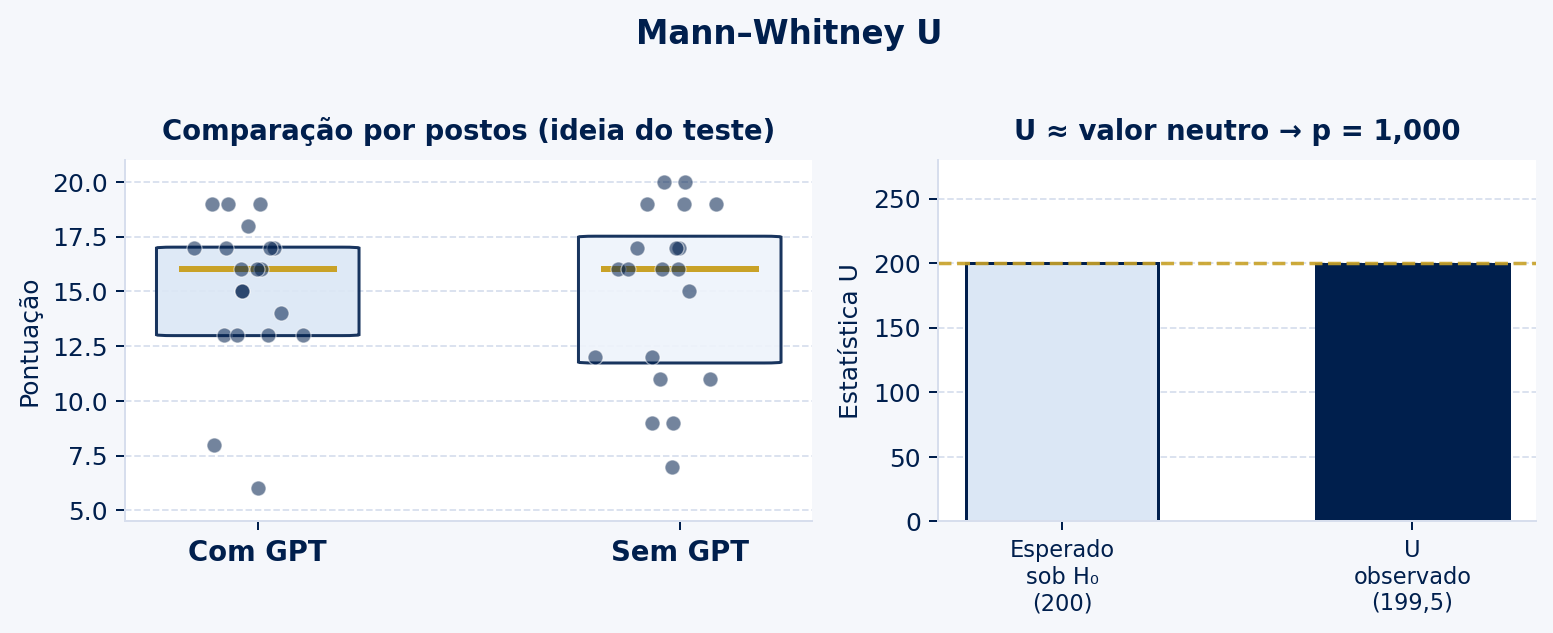

In [ ]:
resultado = mannwhitneyu(
    com_gpt, sem_gpt,
    alternative="two-sided",
    method="asymptotic",
)
u_observado = float(resultado.statistic)
p_valor = float(resultado.pvalue)
u_esperado = len(com_gpt) * len(sem_gpt) / 2

figura, eixos = plt.subplots(
    1, 2, figsize=(8.6, 3.4), dpi=180,
    gridspec_kw={"width_ratios": [1.15, 1]},
)
figura.patch.set_facecolor(FUNDO)

eixo = eixos[0]
estilizar_eixos(eixo)
gerador = np.random.default_rng(7)

grupos = (
    (com_gpt, "Com GPT", "#dbe7f5"),
    (sem_gpt, "Sem GPT", "#eef3fb"),
)

for indice, (valores, _, cor) in enumerate(grupos):
    coordenadas_x = gerador.normal(indice, 0.08, size=len(valores))
    eixo.scatter(
        coordenadas_x, valores,
        s=36, color=AZUL, alpha=0.55,
        edgecolors="white", linewidths=0.5, zorder=3,
    )
    primeiro_quartil, mediana, terceiro_quartil = np.percentile(
        valores, [25, 50, 75]
    )
    eixo.add_patch(
        FancyBboxPatch(
            (indice - 0.22, primeiro_quartil),
            0.44, terceiro_quartil - primeiro_quartil,
            boxstyle="round,pad=0.02,rounding_size=0.04",
            linewidth=1.2, edgecolor=AZUL, facecolor=cor,
            alpha=0.9, zorder=1,
        )
    )
    eixo.plot(
        [indice - 0.18, indice + 0.18], [mediana, mediana],
        color=OURO, linewidth=2.4, zorder=2,
    )

eixo.set_xticks([0, 1])
eixo.set_xticklabels(
    ["Com GPT", "Sem GPT"],
    color=AZUL, fontsize=11, fontweight="bold",
)
eixo.set_ylabel("Pontuação", color=AZUL, fontsize=10)
eixo.set_ylim(4.5, 21)
eixo.set_title(
    "Comparação por postos (ideia do teste)",
    color=AZUL, fontsize=11, fontweight="bold", pad=8,
)

eixo = eixos[1]
estilizar_eixos(eixo)
eixo.bar(
    [0, 1], [u_esperado, u_observado],
    color=["#dbe7f5", AZUL], edgecolor=AZUL,
    width=0.55, linewidth=1.2,
)
eixo.set_xticks([0, 1])
eixo.set_xticklabels(
    [f"Esperado\nsob H₀\n({u_esperado:.0f})",
     f"U\nobservado\n({formatar(u_observado, 1)})"],
    color=AZUL, fontsize=9,
)
eixo.set_ylim(0, 280)
eixo.set_ylabel("Estatística U", color=AZUL, fontsize=10)
eixo.set_title(
    f"U ≈ valor neutro → p = {formatar(p_valor)}",
    color=AZUL, fontsize=11, fontweight="bold", pad=8,
)
eixo.axhline(u_esperado, color=OURO, linestyle="--", linewidth=1.4, alpha=0.9)

figura.suptitle(
    "Mann–Whitney U",
    color=AZUL, fontsize=13, fontweight="bold", y=1.02,
)
figura.tight_layout()

saida = Path(DIRETORIO_SAIDA)
saida.mkdir(parents=True, exist_ok=True)
figura.savefig(
    saida / "grafico-mann-whitney.png",
    dpi=180, bbox_inches="tight", facecolor=FUNDO,
)
plt.show()
plt.close(figura)

## 7. Gráfico — Cliff's Delta

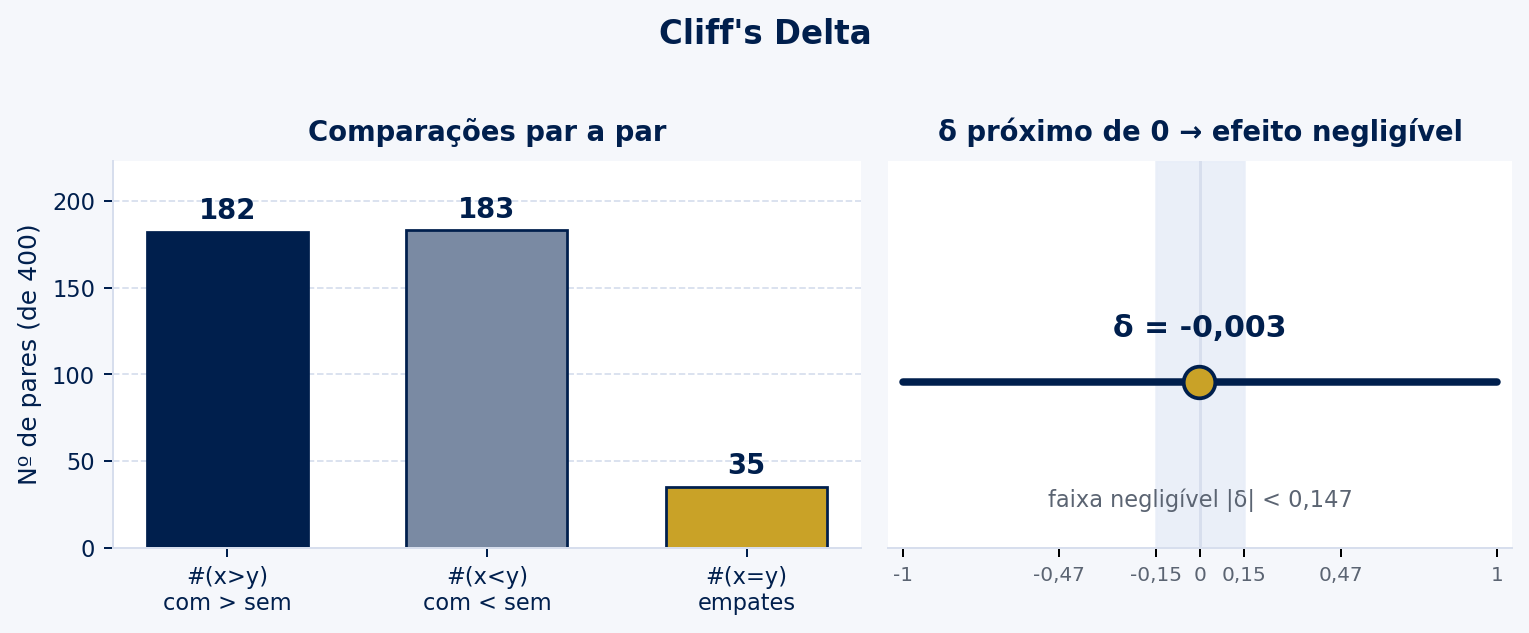

In [ ]:
maiores, menores, empates = contar_pares(com_gpt, sem_gpt)
delta = cliffs_delta(com_gpt.tolist(), sem_gpt.tolist())

figura, eixos = plt.subplots(
    1, 2, figsize=(8.6, 3.4), dpi=180,
    gridspec_kw={"width_ratios": [1.2, 1]},
)
figura.patch.set_facecolor(FUNDO)

eixo = eixos[0]
estilizar_eixos(eixo)
rotulos = ["#(x>y)\ncom > sem", "#(x<y)\ncom < sem", "#(x=y)\nempates"]
contagens = [maiores, menores, empates]
barras = eixo.bar(
    rotulos, contagens,
    color=[AZUL, "#7a8aa3", OURO],
    edgecolor=AZUL, linewidth=1.1, width=0.62,
)

for barra, contagem in zip(barras, contagens, strict=True):
    eixo.text(
        barra.get_x() + barra.get_width() / 2, contagem + 4,
        str(contagem), ha="center", va="bottom",
        color=AZUL, fontsize=11, fontweight="bold",
    )

eixo.set_ylim(0, max(contagens) * 1.22)
eixo.set_ylabel("Nº de pares (de 400)", color=AZUL, fontsize=10)
eixo.tick_params(labelsize=9)
eixo.set_title(
    "Comparações par a par",
    color=AZUL, fontsize=11, fontweight="bold", pad=8,
)

eixo = eixos[1]
eixo.set_facecolor("#ffffff")
eixo.axvline(0, color=BORDA, linewidth=1.2)
eixo.axvspan(-0.147, 0.147, color=AZUL_CLARO, alpha=0.9)
eixo.plot([-1, 1], [0, 0], color=AZUL, linewidth=3, solid_capstyle="round")
eixo.scatter(
    [delta], [0],
    s=160, color=OURO, edgecolors=AZUL, linewidths=1.5, zorder=5,
)
eixo.annotate(
    f"δ = {formatar(delta)}",
    (delta, 0), textcoords="offset points",
    xytext=(0, 18), ha="center",
    color=AZUL, fontsize=12, fontweight="bold",
)
eixo.set_xlim(-1.05, 1.05)
eixo.set_ylim(-0.6, 0.8)
eixo.set_yticks([])
eixo.set_xticks([-1, -0.474, -0.147, 0, 0.147, 0.474, 1])
eixo.set_xticklabels(
    ["-1", "-0,47", "-0,15", "0", "0,15", "0,47", "1"],
    fontsize=8, color=TEXTO_SUAVE,
)
eixo.spines["top"].set_visible(False)
eixo.spines["right"].set_visible(False)
eixo.spines["left"].set_visible(False)
eixo.spines["bottom"].set_color(BORDA)
eixo.set_title(
    "δ próximo de 0 → efeito negligível",
    color=AZUL, fontsize=11, fontweight="bold", pad=8,
)
eixo.text(
    0, -0.45,
    "faixa negligível |δ| < 0,147",
    ha="center", color=TEXTO_SUAVE, fontsize=9,
)

figura.suptitle(
    "Cliff's Delta",
    color=AZUL, fontsize=13, fontweight="bold", y=1.02,
)
figura.tight_layout()
figura.savefig(
    saida / "grafico-cliffs-delta.png",
    dpi=180, bbox_inches="tight", facecolor=FUNDO,
)
plt.show()
plt.close(figura)

## 8. Gráfico — Perfil de uso de IA (TCLE)

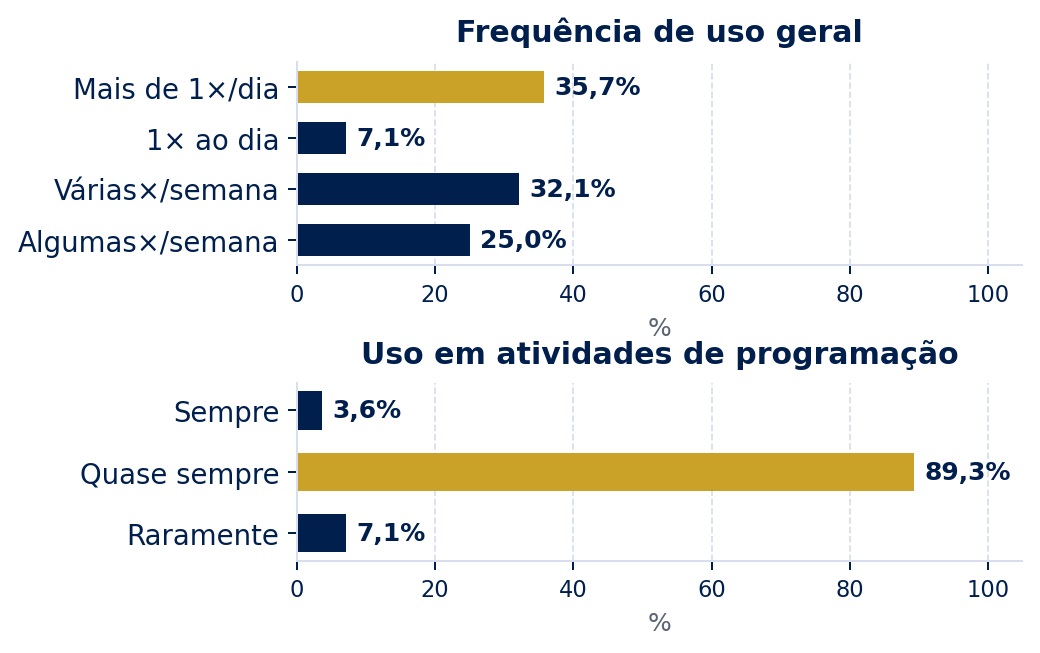

In [ ]:
freq_labels = ["Mais de 1×/dia", "1× ao dia", "Várias×/semana", "Algumas×/semana"]
freq_vals = [35.7, 7.1, 32.1, 25.0]

prog_labels = ["Sempre", "Quase sempre", "Raramente"]
prog_vals = [3.6, 89.3, 7.1]

figura, eixos = plt.subplots(
    2, 1, figsize=(5.2, 3.6), dpi=180,
    gridspec_kw={"height_ratios": [1.15, 1], "hspace": 0.62},
)
figura.patch.set_facecolor("#ffffff")

for eixo, labels, valores, titulo in (
    (eixos[0], freq_labels, freq_vals, "Frequência de uso geral"),
    (eixos[1], prog_labels, prog_vals, "Uso em atividades de programação"),
):
    y = np.arange(len(labels))
    cores = [OURO if v == max(valores) else AZUL for v in valores]
    barras = eixo.barh(y, valores, color=cores, height=0.62, edgecolor="none")
    eixo.set_yticks(y)
    eixo.set_yticklabels(labels, fontsize=11, color=AZUL)
    eixo.set_xlim(0, 105)
    eixo.set_xlabel("%", fontsize=10, color=TEXTO_SUAVE)
    eixo.set_title(titulo, fontsize=12, fontweight="bold", color=AZUL, pad=8)
    eixo.invert_yaxis()
    estilizar_eixos(eixo)
    eixo.set_facecolor("#ffffff")
    eixo.xaxis.grid(True, color=BORDA, linestyle="--", linewidth=0.7)
    eixo.yaxis.grid(False)
    eixo.tick_params(axis="x", labelsize=9)

    for barra, valor in zip(barras, valores):
        eixo.text(
            valor + 1.5, barra.get_y() + barra.get_height() / 2,
            f"{formatar(valor, 1)}%", va="center", ha="left",
            fontsize=10, fontweight="bold", color=AZUL,
        )

figura.savefig(
    saida / "grafico-perfil-ia.png",
    dpi=180, bbox_inches="tight",
    facecolor="#ffffff", pad_inches=0.12,
)
plt.show()
plt.close(figura)

## 9. Arquivos salvos

In [ ]:
print("Gráficos salvos em:", DIRETORIO_SAIDA)
for p in saida.iterdir():
    if p.suffix == ".png":
        print(f"  {p.name}")

Gráficos salvos em: /content/drive/MyDrive/Colab Notebooks/codigo projeto tcc/
  grafico-mann-whitney.png
  grafico-cliffs-delta.png
  grafico-perfil-ia.png
